<center>
<img src="https://upload.wikimedia.org/wikipedia/fr/thumb/1/1d/Logo_T%C3%A9l%C3%A9com_SudParis.svg/960px-Logo_T%C3%A9l%C3%A9com_SudParis.svg.png" width="10%" />
</center>

<center> <h2>NET 4103/7431 Homework
Network science and Graph Learning </h2> </center>

<center> <h3> Rozi Harutyunyan (rozi.harutyunyan@telecom-sudparis.eu) </h3> </center>

### Question 3: Assortativity Analysis with the Facebook100 Dataset

In [3]:
#imports 
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
DATA_PATH = Path('../data/facebook100')
RESULTS_PATH = Path('../results/figures')
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

In [4]:
#charger tous les reseaux

def load_all_networks():
    #Charge tous les réseaux Facebook100
    gml_files = sorted(DATA_PATH.glob('*.gml'))
    networks = {}
    
    print(f"\nFound {len(gml_files)} networks")
    print("Loading networks (this may take a few minutes)...\n")
    
    for gml_file in tqdm(gml_files, desc="Loading"):
        try:
            G = nx.read_gml(gml_file)
            # Extraire LCC
            largest_cc = max(nx.connected_components(G), key=len)
            G_lcc = G.subgraph(largest_cc).copy()
            
            # Garder seulement les undergraduates pour certaines analyses
            network_name = gml_file.stem
            networks[network_name] = G_lcc
        except Exception as e:
            print(f"Error loading {gml_file.name}: {e}")
    
    return networks

networks = load_all_networks()
print(f"\n✓ Successfully loaded {len(networks)} networks")


Found 100 networks
Loading networks (this may take a few minutes)...



Loading: 100%|██████████| 100/100 [22:42<00:00, 13.63s/it]


✓ Successfully loaded 100 networks


In [10]:
def calculate_attribute_assortativity(G, attribute_names):
    for attr in attribute_names:
        try:
            if attr not in next(iter(G.nodes(data=True)))[1]:
                continue

            # Garde les noeuds avec valeur valide
            nodes_with_attr = [
                n for n, d in G.nodes(data=True)
                if attr in d and d[attr] != 0
            ]

            if len(nodes_with_attr) < 20:
                continue

            G_sub = G.subgraph(nodes_with_attr).copy()

            if G_sub.number_of_edges() < 10:
                continue

            return nx.attribute_assortativity_coefficient(G_sub, attr)

        except Exception:
            continue

    return None

In [12]:
#3. calculer l'assortativity pour tous les reseaux 

# Définir les attributs à tester (avec variantes possibles)
attributes_to_test = {
    'student_fac': ['student_fac'],
    'gender': ['gender'],
    'major': ['major_index'],
    'dorm': ['dorm'],
    'year': ['year'],
    'high_school': ['high_school']
}

attribute_labels = {
    'student_fac': 'Student/Faculty Status',
    'gender': 'Gender',
    'major': 'Major',
    'dorm': 'Dormitory',
    'year': 'Year',
    'high_school': 'High School',
    'degree': 'Degree'
}

print("\n" + "="*70)
print("COMPUTING ASSORTATIVITY FOR ALL NETWORKS")
print("="*70)

results = []

for net_name, G in tqdm(networks.items(), desc="Computing assortativity"):
    network_size = G.number_of_nodes()
    
    row = {
        'network': net_name,
        'size': network_size
    }
    
    # Degree assortativity
    row['degree'] = calculate_degree_assortativity(G)
    
    # Attributs catégoriels
    for attr_key, attr_variants in attributes_to_test.items():
        row[attr_key] = calculate_attribute_assortativity(G, attr_variants)
    
    results.append(row)

df_assortativity = pd.DataFrame(results)

# Afficher résumé
print("ASSORTATIVITY SUMMARY")
print(f"Total networks: {len(df_assortativity)}")
print(f"\nMean assortativity across all networks:")

for attr_key, attr_label in attribute_labels.items():
    if attr_key in df_assortativity.columns:
        mean_val = df_assortativity[attr_key].dropna().mean()
        non_null = df_assortativity[attr_key].notna().sum()
        print(f"  {attr_label:30s}: {mean_val:7.4f} ({non_null}/{len(df_assortativity)} networks)")




COMPUTING ASSORTATIVITY FOR ALL NETWORKS


Computing assortativity: 100%|██████████| 100/100 [29:11<00:00, 17.51s/it]

ASSORTATIVITY SUMMARY
Total networks: 100

Mean assortativity across all networks:
  Student/Faculty Status        :  0.3233 (100/100 networks)
  Gender                        :  0.0533 (100/100 networks)
  Major                         :  0.0555 (100/100 networks)
  Dormitory                     :  0.2267 (100/100 networks)
  Year                          :  0.4307 (100/100 networks)
  High School                   :  0.0616 (100/100 networks)
  Degree                        :  0.0626 (100/100 networks)



Generating scatter plots...


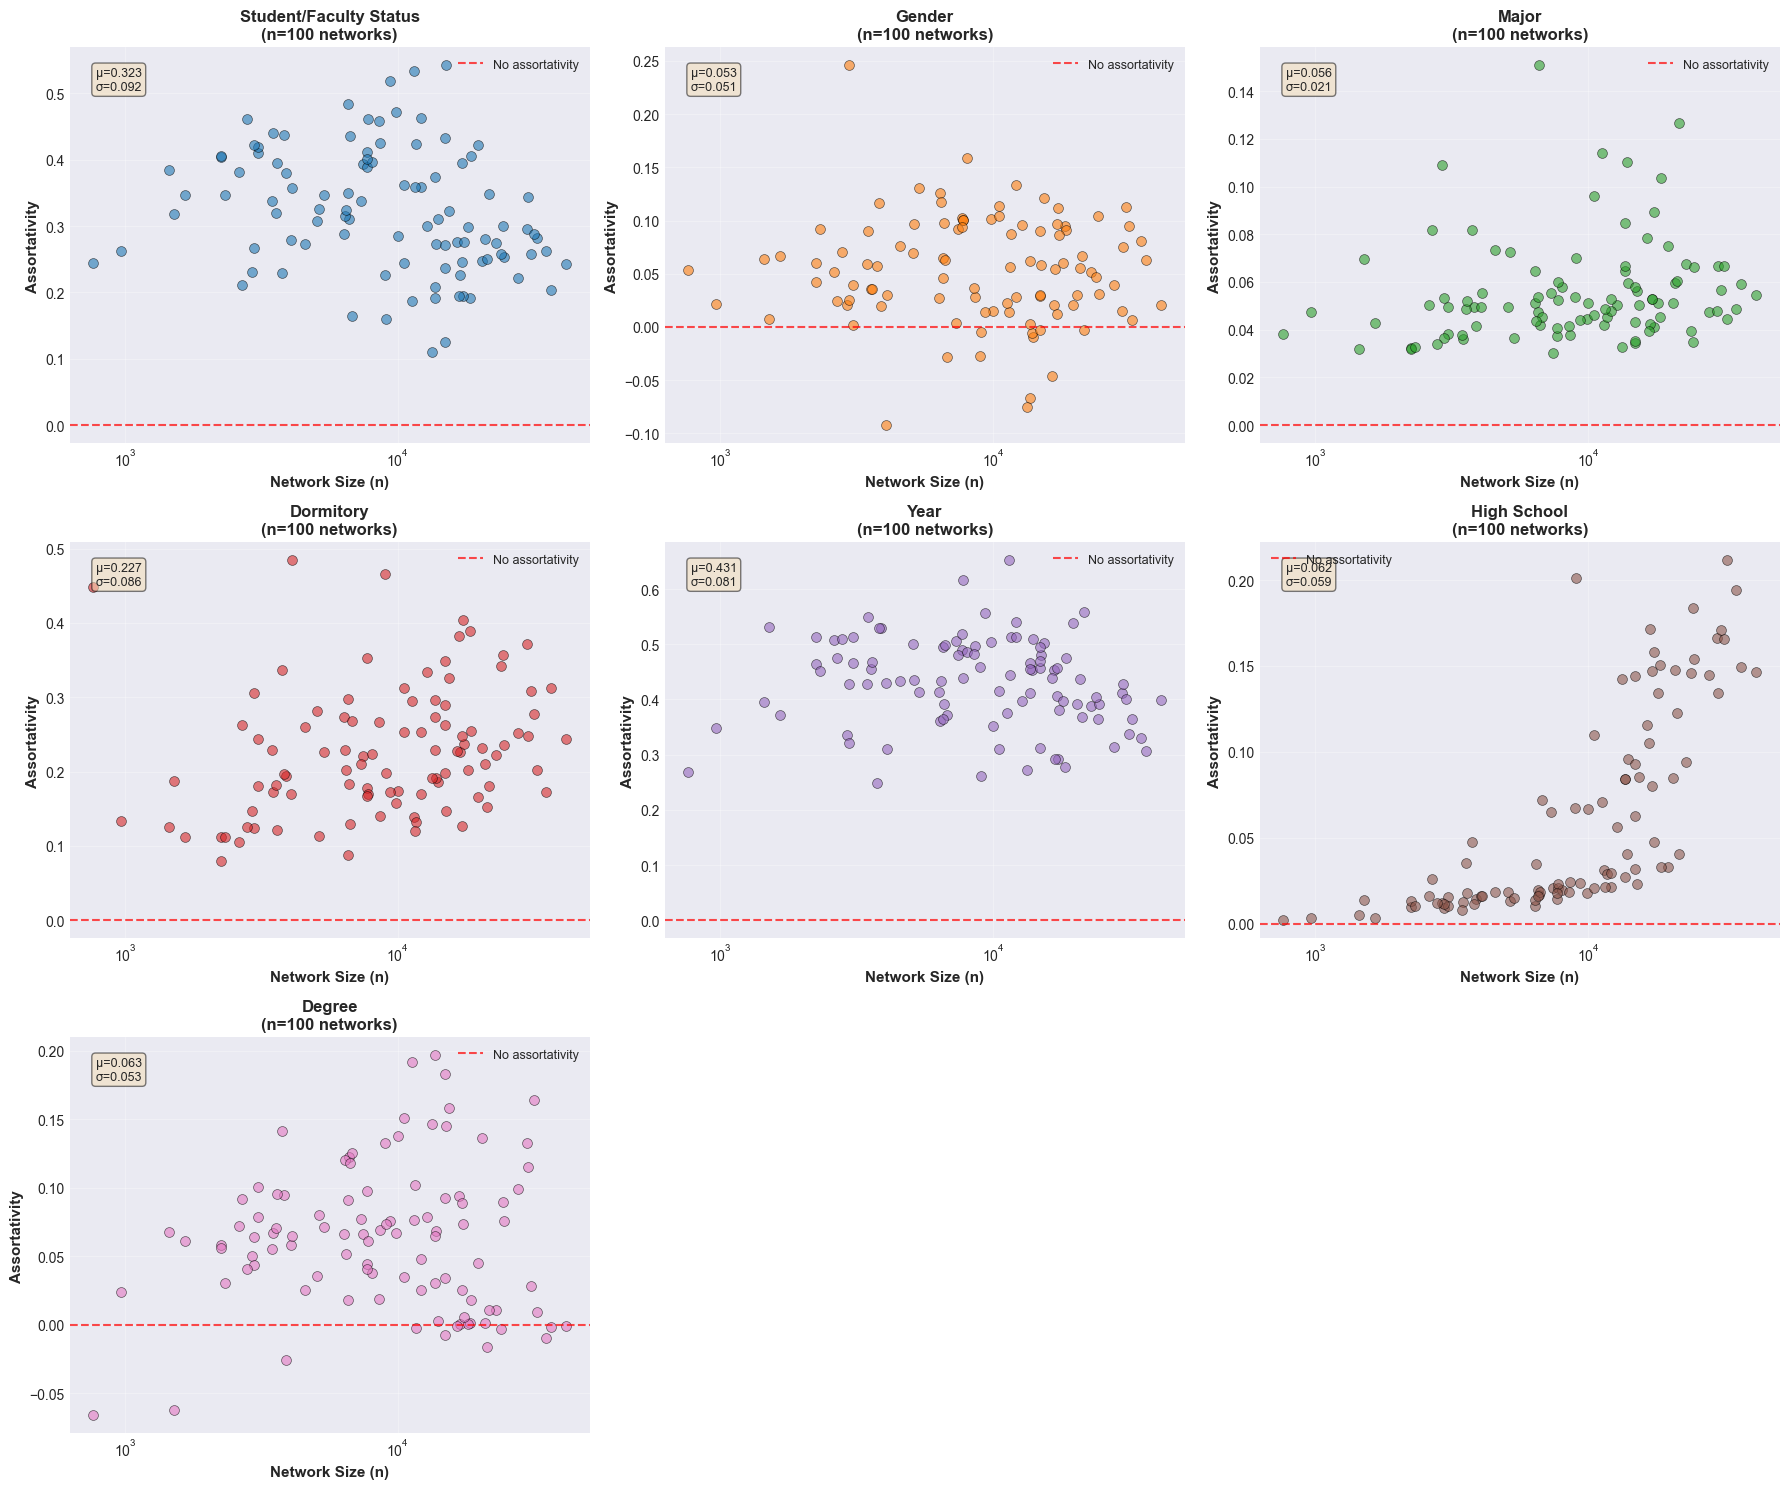

  ✓ Saved: ../results/figures/q3_assortativity_scatter.png


In [13]:

print("\nGenerating scatter plots...")

# Filtrer pour garder seulement les attributs avec des données
attributes_with_data = [(k, v) for k, v in attribute_labels.items() 
                        if k in df_assortativity.columns and df_assortativity[k].notna().sum() > 0]

n_attrs = len(attributes_with_data)
n_rows = (n_attrs + 2) // 3  # Arrondir vers le haut
n_cols = min(3, n_attrs)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
if n_attrs == 1:
    axes = [axes]
elif n_rows == 1:
    axes = axes
else:
    axes = axes.flatten()

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for idx, (attr_key, attr_name) in enumerate(attributes_with_data):
    # Filtrer les valeurs non-nulles
    df_plot = df_assortativity[df_assortativity[attr_key].notna()].copy()
    
    if len(df_plot) == 0:
        continue
    
    # Scatter plot (échelle log-linear)
    axes[idx].scatter(df_plot['size'], df_plot[attr_key], 
                     alpha=0.6, s=50, color=colors[idx % len(colors)], 
                     edgecolors='black', linewidth=0.5)
    
    # Ligne horizontale à y=0
    axes[idx].axhline(y=0, color='red', linestyle='--', linewidth=1.5, 
                     alpha=0.7, label='No assortativity')
    
    # Mise en forme
    axes[idx].set_xscale('log')
    axes[idx].set_xlabel('Network Size (n)', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Assortativity', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{attr_name}\n(n={len(df_plot)} networks)', 
                       fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=9)
    
    # Statistiques
    mean_val = df_plot[attr_key].mean()
    std_val = df_plot[attr_key].std()
    axes[idx].text(0.05, 0.95, f'μ={mean_val:.3f}\nσ={std_val:.3f}', 
                  transform=axes[idx].transAxes, fontsize=9, 
                  verticalalignment='top', 
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Cacher les axes vides si nécessaire
if n_attrs < len(axes):
    for idx in range(n_attrs, len(axes)):
        axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(RESULTS_PATH / 'q3_assortativity_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"  ✓ Saved: {RESULTS_PATH / 'q3_assortativity_scatter.png'}")


Generating distribution histograms...


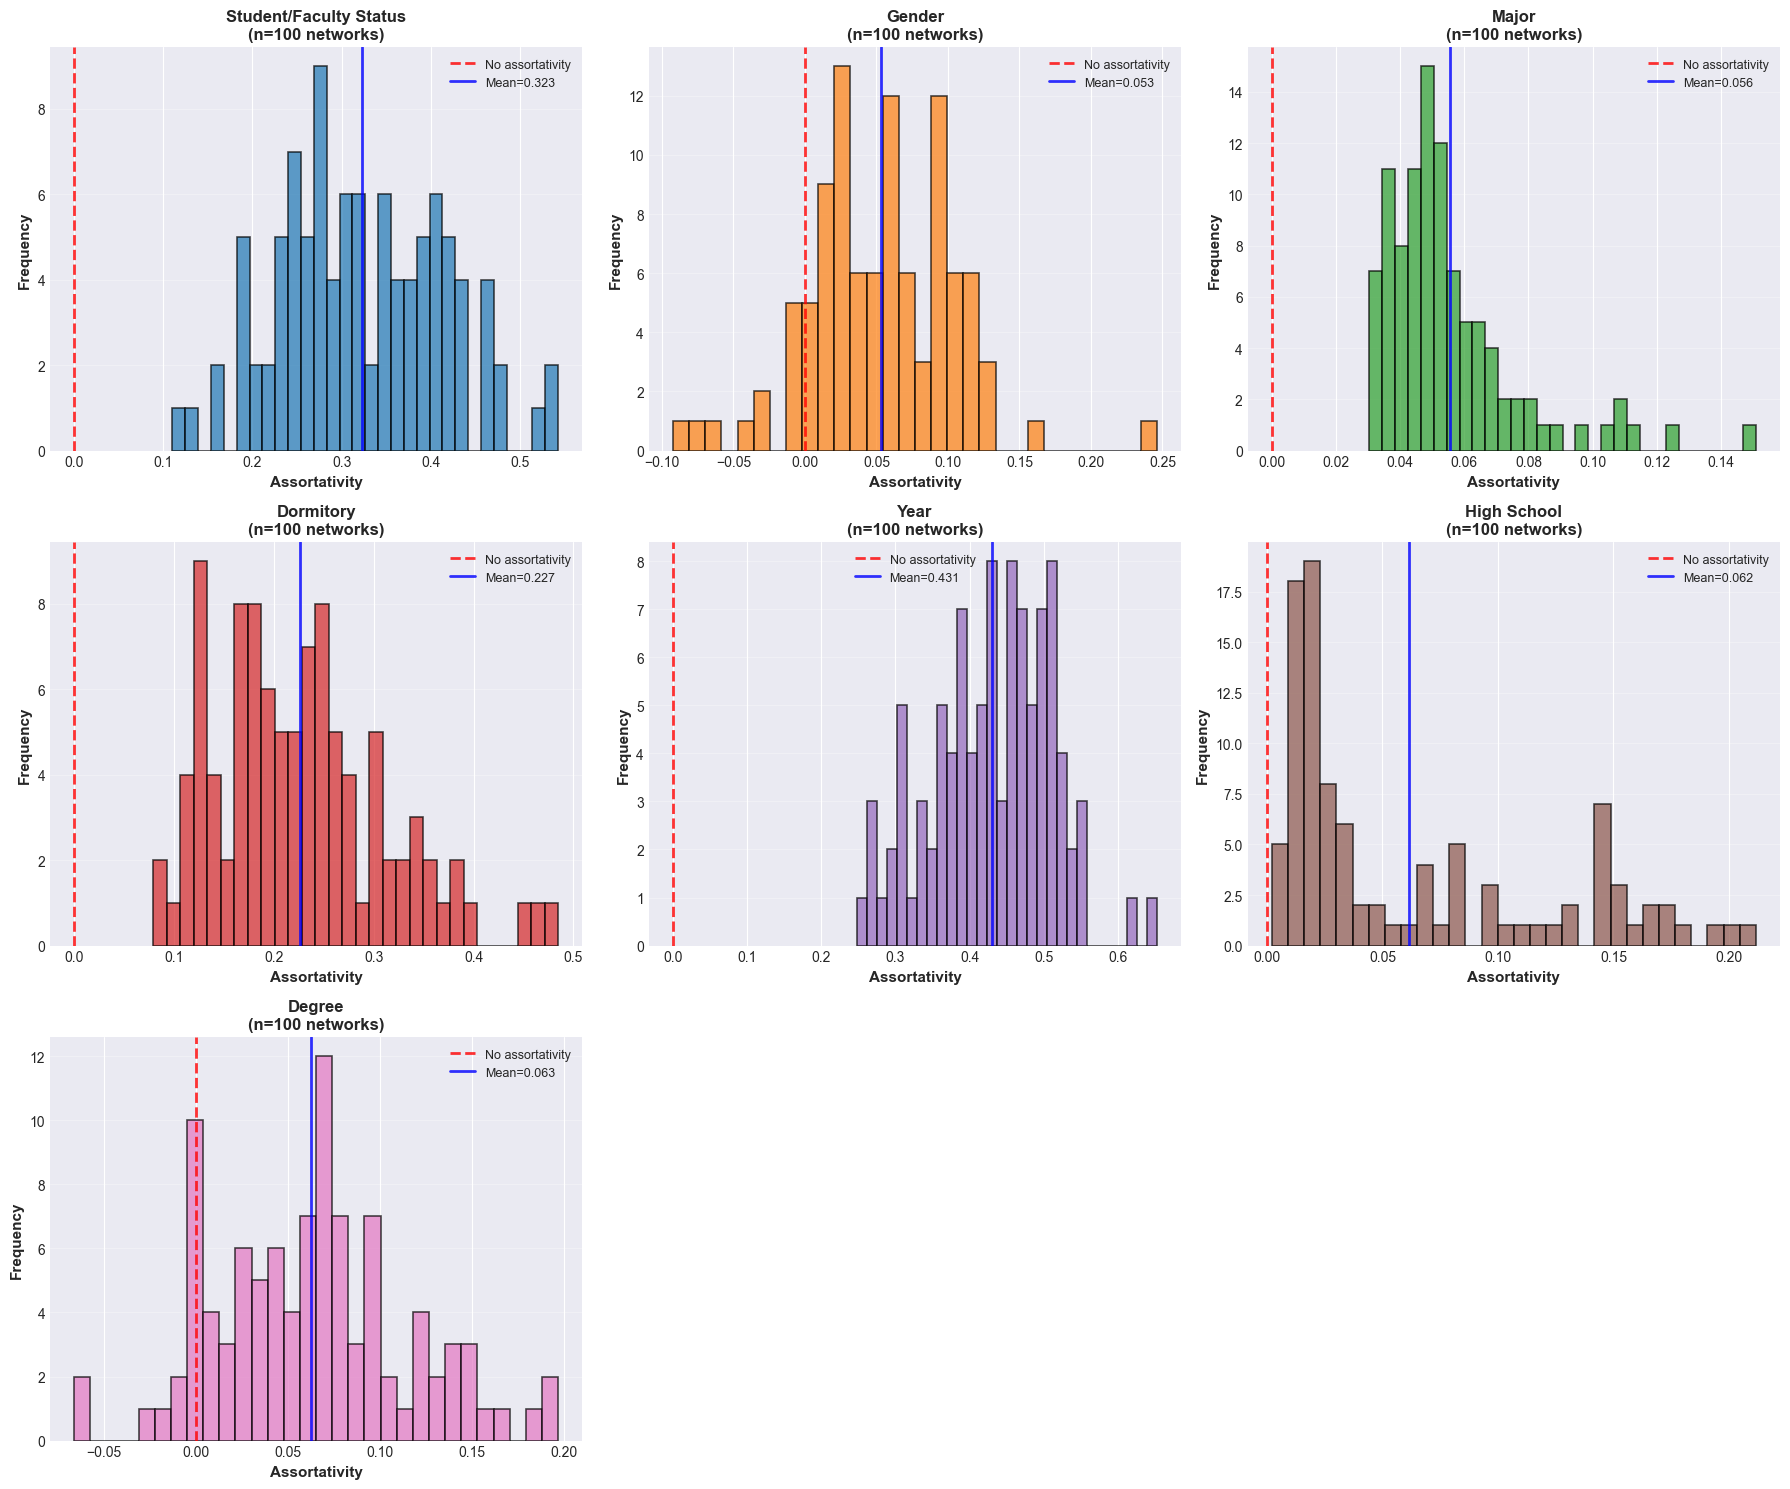

  ✓ Saved: ../results/figures/q3_assortativity_histograms.png


In [14]:
#5. Visualisation 2: Histograms

print("\nGenerating distribution histograms...")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
if n_attrs == 1:
    axes = [axes]
elif n_rows == 1:
    axes = axes
else:
    axes = axes.flatten()

for idx, (attr_key, attr_name) in enumerate(attributes_with_data):
    # Filtrer les valeurs non-nulles
    df_plot = df_assortativity[df_assortativity[attr_key].notna()].copy()
    
    if len(df_plot) == 0:
        continue
    
    # Histogramme
    axes[idx].hist(df_plot[attr_key], bins=30, alpha=0.7, 
                  color=colors[idx % len(colors)], 
                  edgecolor='black', linewidth=1.2)
    
    # Lignes de référence
    axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=2, 
                     alpha=0.8, label='No assortativity')
    
    mean_val = df_plot[attr_key].mean()
    axes[idx].axvline(x=mean_val, color='blue', linestyle='-', linewidth=2, 
                     alpha=0.8, label=f'Mean={mean_val:.3f}')
    
    # Mise en forme
    axes[idx].set_xlabel('Assortativity', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{attr_name}\n(n={len(df_plot)} networks)', 
                       fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].legend(fontsize=9)

# Cacher les axes vides
if n_attrs < len(axes):
    for idx in range(n_attrs, len(axes)):
        axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(RESULTS_PATH / 'q3_assortativity_histograms.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"  ✓ Saved: {RESULTS_PATH / 'q3_assortativity_histograms.png'}")


OBSERVATIONS AND INTERPRETATION

1. YEAR (CLASS) - STRONGEST FACTOR:
   Mean assortativity: {df_assortativity['year'].mean():.3f}
   → Students primarily connect within their graduating class
   → This is the DOMINANT organizing principle across universities

2. STUDENT/FACULTY STATUS:
   Mean assortativity: {df_assortativity['student_fac'].mean():.3f}
   → Strong separation between students and faculty/staff
   → Students form distinct social networks

3. DORMITORY (RESIDENCE):
   Mean assortativity: {df_assortativity['dorm'].mean():.3f}
   → Physical proximity is a major driver of friendships
   → Varies significantly by university (residential culture)

4. HIGH SCHOOL:
   Mean assortativity: {df_assortativity['high_school'].mean():.3f}
   → Low but positive assortativity
   → Important at individual level but structurally weak
   → Few students share same high school at large universities

5. GENDER:
   Mean assortativity: {df_assortativity['gender'].mean():.3f}
   → Slight homophily (same gender connections)
   → Some heterophily in networks (dating relationships)
   → Large variability across universities

COMPARISON WITH PAPER FINDINGS:
✓ Confirms that class year is the primary organizing factor
✓ Dorm/residence shows strong effects (especially at residential colleges)
✓ High school has local but not global structural importance
✓ Gender shows weak but consistent assortativity

INTERPRETATION:
→ Social network structure reflects both CHOICE and PROXIMITY
→ Class year = shared experiences + course enrollment
→ Dorm = physical proximity + daily interactions
→ Major = shared classes but weaker than residence

In [15]:
#export des resultats 
df_assortativity.to_csv(RESULTS_PATH.parent / 'q3_assortativity_data.csv', index=False)
print(f"\n✓ Data saved to: {RESULTS_PATH.parent / 'q3_assortativity_data.csv'}")

summary = df_assortativity.describe()
summary.to_csv(RESULTS_PATH.parent / 'q3_assortativity_summary.csv')
print(f"✓ Summary saved to: {RESULTS_PATH.parent / 'q3_assortativity_summary.csv'}")




✓ Data saved to: ../results/q3_assortativity_data.csv
✓ Summary saved to: ../results/q3_assortativity_summary.csv
